In [36]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns

In [37]:
conn = sqlite3.connect('data/checking-logs.sqlite')

In [38]:
project1 = pd.io.sql.read_sql(
    "SELECT uid, numTrials, timestamp FROM checker WHERE uid LIKE 'user_%' AND status = 'ready' AND labname = 'project1' ORDER BY uid;",
    conn,
    parse_dates=['timestamp']
)
project1

,uid,numTrials,timestamp
0,user_1,1,2020-05-14 20:56:08.898880
1,user_1,2,2020-05-14 20:58:02.313690
2,user_1,3,2020-05-14 20:58:46.322457
3,user_1,4,2020-05-14 21:08:15.434237
4,user_1,5,2020-05-14 21:10:14.867603
...,...,...,...
946,user_8,4,2020-05-14 16:18:00.528528
947,user_8,5,2020-05-14 16:41:03.916147
948,user_8,6,2020-05-14 17:40:47.781946
949,user_8,7,2020-05-14 17:46:54.469822


In [39]:
project1 = project1.sort_values('timestamp').sort_values('uid')
project1

,uid,numTrials,timestamp
7,user_1,8,2020-05-14 21:21:00.651643
5,user_1,6,2020-05-14 21:12:49.812670
0,user_1,1,2020-05-14 20:56:08.898880
2,user_1,3,2020-05-14 20:58:46.322457
8,user_1,9,2020-05-14 21:23:00.570667
...,...,...,...
944,user_8,2,2020-05-14 15:50:51.715993
950,user_8,8,2020-05-14 21:12:17.314337
945,user_8,3,2020-05-14 16:11:00.491523
948,user_8,6,2020-05-14 17:40:47.781946


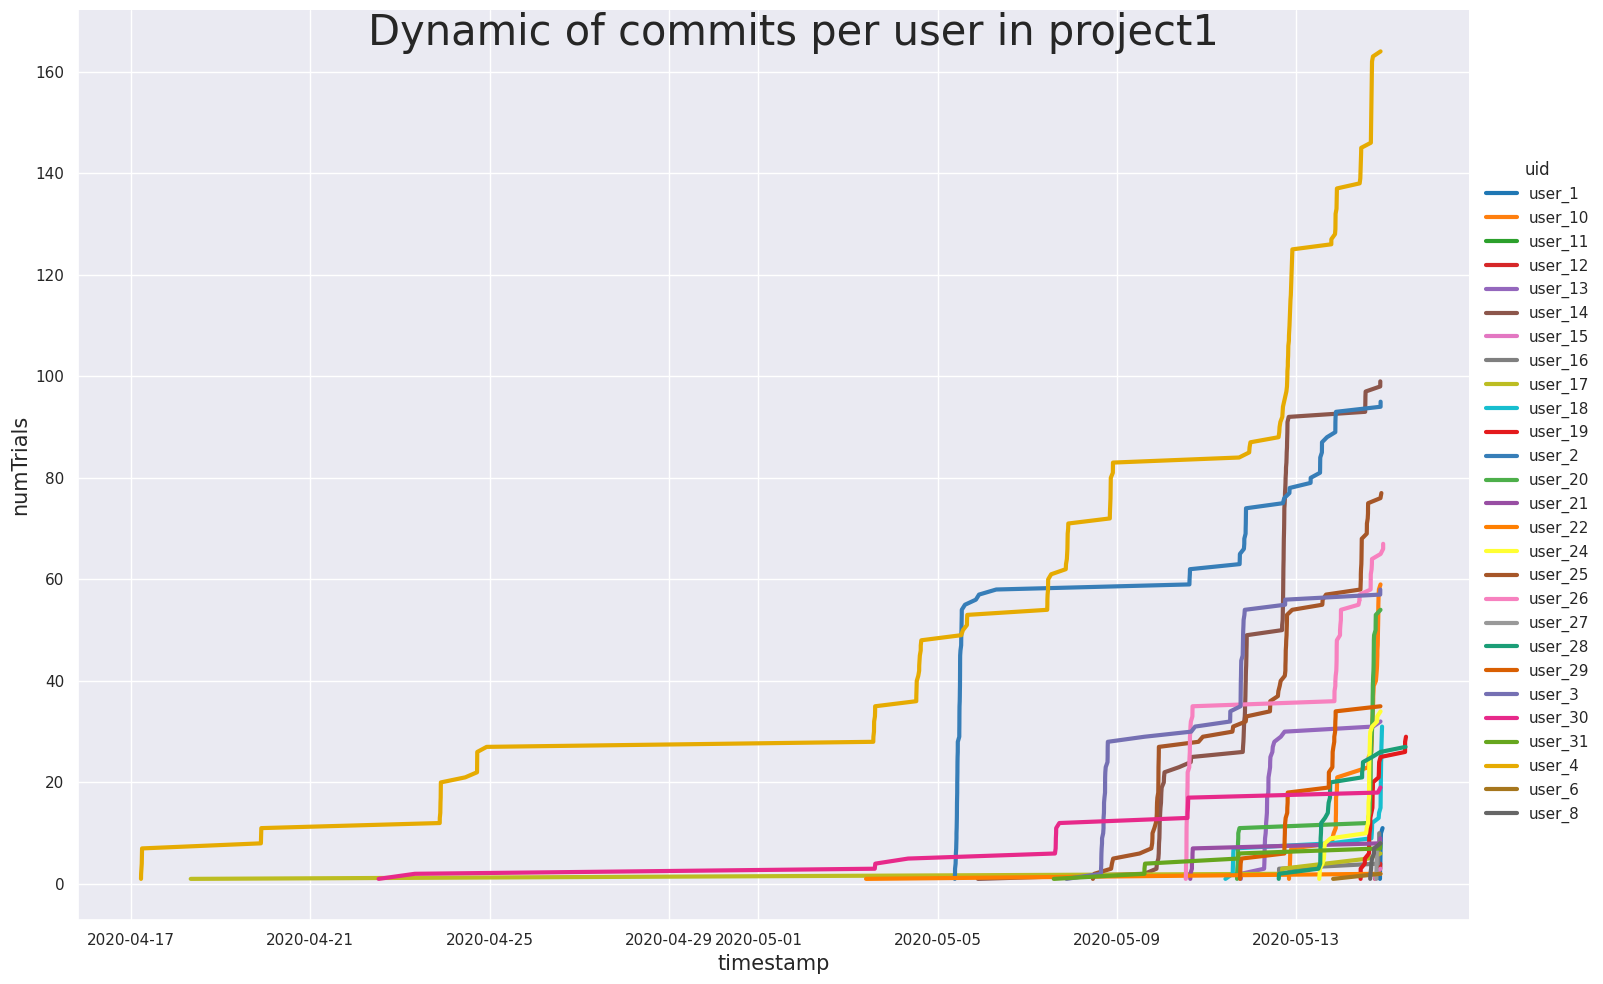

In [40]:
sns.set(rc={'axes.labelsize': 15, 'lines.linewidth': 3})
unique_users = project1['uid'].unique()
n_colors = len(unique_users)
colors = (sns.color_palette('tab10') + sns.color_palette('Set1') +
          sns.color_palette('Dark2') + sns.color_palette('Set2'))[:n_colors]
palette_dict = dict(zip(unique_users, colors))
sns.relplot(data=project1, x='timestamp', y='numTrials', hue='uid',
            hue_order=unique_users, palette=palette_dict, kind='line',
            legend='full', height=10, aspect=1.5)
plt.suptitle('Dynamic of commits per user in project1', fontsize=30)
plt.show()

In [41]:
conn.close()

Какой пользователь был лидером по числу коммитов почти все время?

**user_4**

Какой пользователь был лидером только короткий срок?

**user_2**